<h1>Libraries & Imports

In [ ]:
# !pip install matplotlib
# !pip install seaborn
# !pip install pyspark
# !pip install torch
# !pip install torch torchvision

In [6]:
import torch
import torchvision

<h1>Check for GPU

In [8]:
def get_device():
    """
    Automatically detect and return the best available device.
    
    Priority: CUDA > MPS > CPU
    
    Returns:
        str: Device name for Ultralytics ('cuda', 'mps', or 'cpu')
    """
    if torch.cuda.is_available():
        device = 'cuda'
        print(f"✓ Using CUDA (NVIDIA GPU)")
        print(f"  GPU Name: {torch.cuda.get_device_name(0)}")
        print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = 'mps'
        print(f"✓ Using MPS (Apple Silicon GPU)")
        print(f"  🍎 Your Mac's GPU will accelerate inference!")
        print(f"  Note: MPS provides excellent performance on M1/M2/M3 Macs")
    else:
        device = 'cpu'
        print(f"✓ Using CPU")
        print(f"  Note: Inference will be slower. Consider using a GPU-enabled device.")
    
    return device

# Set up the device
device = get_device()

print(f"\n📱 Device Configuration:")
print(f"  Active Device: {device}")
print(f"  PyTorch version: {torch.__version__}")

if device == 'cuda':
    print(f"  CUDA Version: {torch.version.cuda}")
elif device == 'mps':
    print(f"  MPS Backend: Enabled ✅")
    print(f"  Perfect for: M1, M2, M3 MacBooks and iMacs")
else:
    print(f"  CPU Cores: {os.cpu_count()}")
    
print(f"\nThis device will be used for training and inference.")

✓ Using MPS (Apple Silicon GPU)
  🍎 Your Mac's GPU will accelerate inference!
  Note: MPS provides excellent performance on M1/M2/M3 Macs

📱 Device Configuration:
  Active Device: mps
  PyTorch version: 2.10.0
  MPS Backend: Enabled ✅
  Perfect for: M1, M2, M3 MacBooks and iMacs

This device will be used for training and inference.


In [9]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("TestApp") \
    .getOrCreate()

# spark.stop()

<h1>Download Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("murtadhanajim/gender-recognition-by-voiceoriginal")

print("Path to dataset files:", path)

/Users/purin/nganduan/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.31G/1.31G [01:29<00:00, 15.8MB/s]

Extracting files...


Path to dataset files: /Users/purin/.cache/kagglehub/datasets/murtadhanajim/gender-recognition-by-voiceoriginal/versions/1


<h1>EDA

In [15]:
import os
import glob
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set the path to your local dataset folder
DATASET_PATH = "dataset"

# Updated to match your lowercase subfolders
male_files = glob.glob(os.path.join(DATASET_PATH, 'male', '*.wav'))
female_files = glob.glob(os.path.join(DATASET_PATH, 'female', '*.wav'))

print(f"Total Male audio files: {len(male_files)}")
print(f"Total Female audio files: {len(female_files)}")

Total Male audio files: 10380
Total Female audio files: 5768


We can see that the data is unbalance from the total number of the files

Checking the Metadata & Distribution. Before processing the spectrograms, we need to understand the duration and sample rates of the audio files

Processing female: 100%|██████████| 1000/1000 [00:00<00:00, 1324.58it/s]


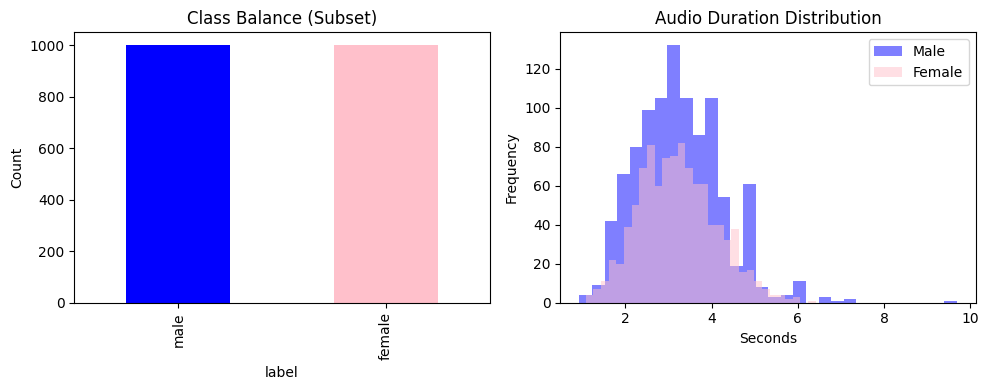


Sample Rates found in dataset: [16000]


In [16]:
def get_audio_metadata(file_paths, label, max_files=1000):
    metadata = []
    for filepath in tqdm(file_paths[:max_files], desc=f"Processing {label}"):
        try:
            # sr=None preserves the original sampling rate
            y, sr = librosa.load(filepath, sr=None) 
            duration = librosa.get_duration(y=y, sr=sr)
            metadata.append({
                'label': label,
                'duration': duration,
                'sample_rate': sr
            })
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            
    return metadata

# Extract metadata
male_meta = get_audio_metadata(male_files, 'male')
female_meta = get_audio_metadata(female_files, 'female')

df_meta = pd.DataFrame(male_meta + female_meta)

# --- PLOTS: Class Balance & Duration ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df_meta['label'].value_counts().plot(kind='bar', color=['blue', 'pink'])
plt.title('Class Balance (Subset)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(df_meta[df_meta['label']=='male']['duration'], bins=30, alpha=0.5, label='Male', color='blue')
plt.hist(df_meta[df_meta['label']=='female']['duration'], bins=30, alpha=0.5, label='Female', color='pink')
plt.title('Audio Duration Distribution')
plt.xlabel('Seconds')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

print("\nSample Rates found in dataset:", df_meta['sample_rate'].unique())

Time-Domain & Frequency-Domain Analysis

Now we will load one male and one female audio file to compare their raw waveforms (time) and their pitch/frequencies via Fast Fourier Transform (FFT).

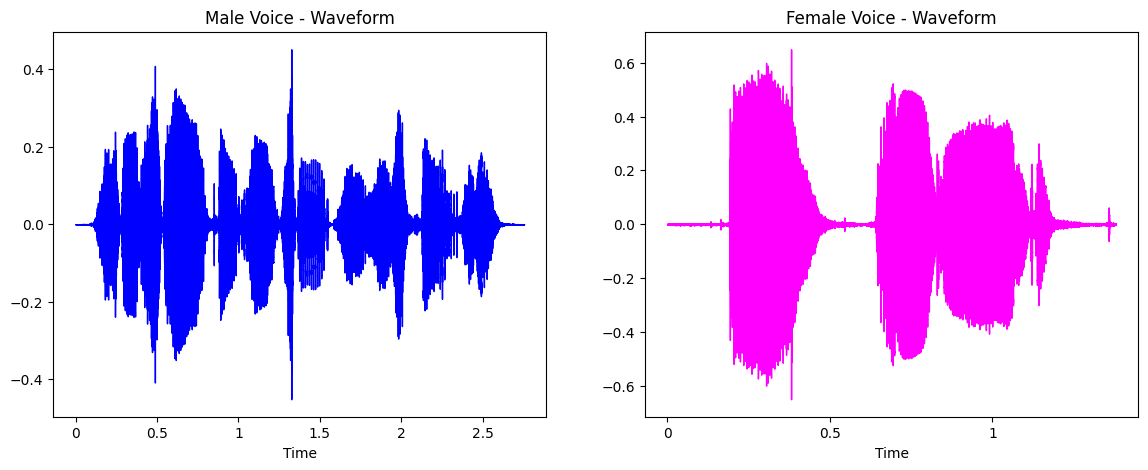

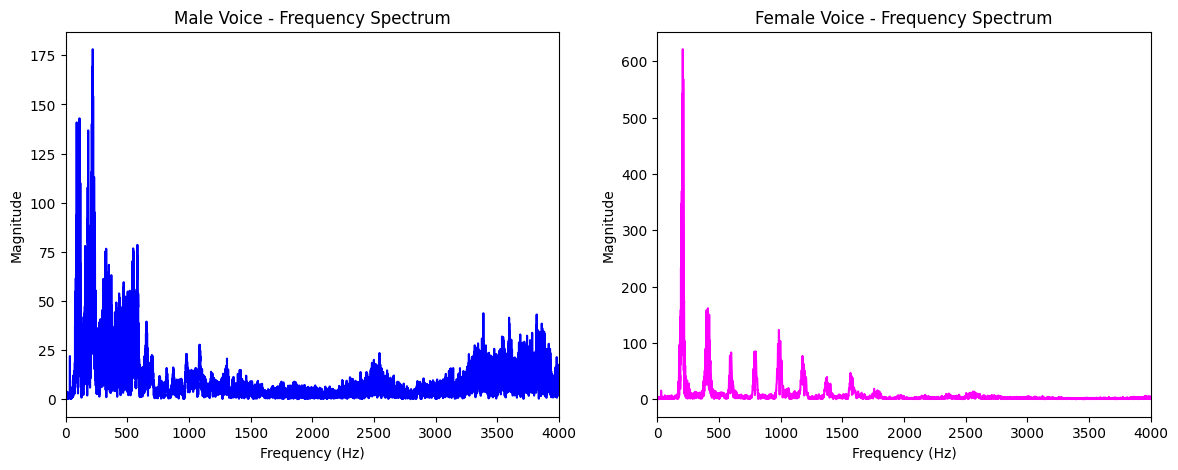

In [17]:
# Select one random file from each class safely
if male_files and female_files:
    sample_male = male_files[0]
    sample_female = female_files[0]
else:
    raise ValueError("Could not find audio files. Please check your folder structure.")

# Force a standard sample rate of 16kHz for consistency
SR = 16000
y_male, _ = librosa.load(sample_male, sr=SR)
y_female, _ = librosa.load(sample_female, sr=SR)

# --- PLOTS: Waveforms (Time Domain) ---
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
librosa.display.waveshow(y_male, sr=SR, color="blue")
plt.title("Male Voice - Waveform")

plt.subplot(1, 2, 2)
librosa.display.waveshow(y_female, sr=SR, color="magenta")
plt.title("Female Voice - Waveform")
plt.show()

# --- PLOTS: FFT / Spectrum (Frequency Domain) ---
def plot_fft(y, sr, title, color):
    fft = np.fft.fft(y)
    magnitude = np.abs(fft)
    frequency = np.linspace(0, sr, len(magnitude))
    half_length = int(len(frequency) / 2)
    
    plt.plot(frequency[:half_length], magnitude[:half_length], color=color)
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 4000) # Limit to 4kHz 

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plot_fft(y_male, SR, "Male Voice - Frequency Spectrum", "blue")

plt.subplot(1, 2, 2)
plot_fft(y_female, SR, "Female Voice - Frequency Spectrum", "magenta")
plt.show()

Time-Frequency Analysis (Mel Spectrograms)

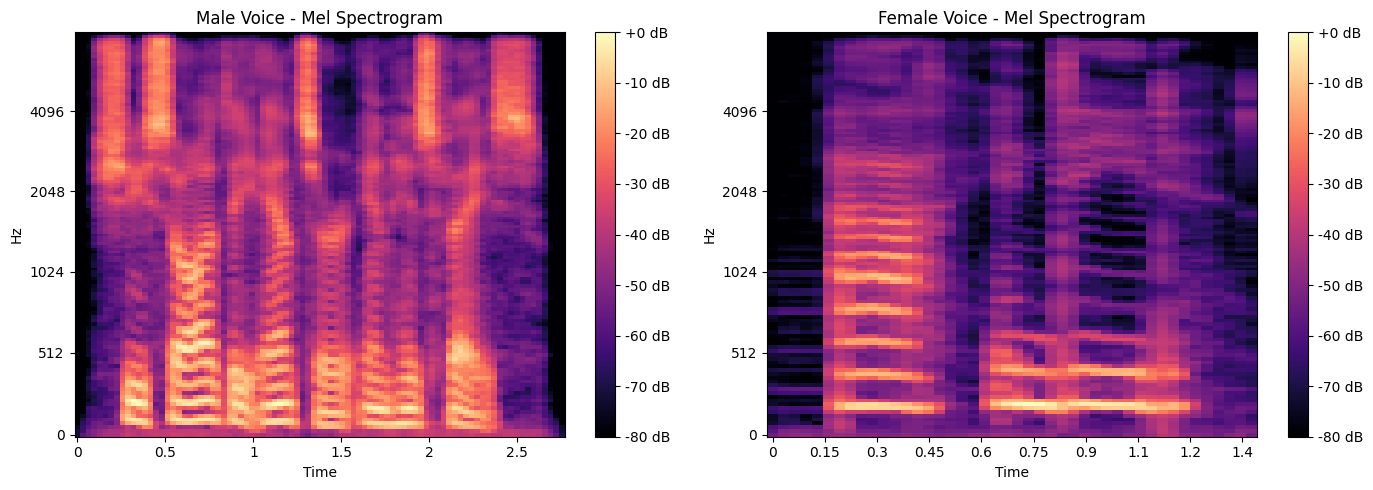

In [18]:
def plot_mel_spectrogram(y, sr, title):
    # Create the Mel Spectrogram
    mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
    
    # Convert power to Decibels (Log scale)
    mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)
    
    # Plot
    librosa.display.specshow(mel_spect_db, sr=sr, hop_length=512, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)

plt.figure(figsize=(14, 5))

# --- PLOTS: Mel Spectrograms ---
plt.subplot(1, 2, 1)
plot_mel_spectrogram(y_male, SR, "Male Voice - Mel Spectrogram")

plt.subplot(1, 2, 2)
plot_mel_spectrogram(y_female, SR, "Female Voice - Mel Spectrogram")

plt.tight_layout()
plt.show()

Checking the sampling rate of the files

In [19]:
import os
import glob
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm
import hashlib

DATASET_PATH = "dataset"
all_files = glob.glob(os.path.join(DATASET_PATH, '**', '*.wav'), recursive=True)

def check_sampling_rates(file_list):
    rates = []
    # Scanning all files (using librosa.core.get_samplerate is much faster than loading the whole file)
    for f in tqdm(file_list, desc="Checking Sample Rates"):
        try:
            sr = librosa.get_samplerate(f)
            rates.append(sr)
        except Exception as e:
            print(f"Error reading {f}: {e}")
            
    df_rates = pd.DataFrame(rates, columns=['Sample Rate'])
    rate_counts = df_rates['Sample Rate'].value_counts()
    
    print("\n--- Sampling Rate Distribution ---")
    print(rate_counts)
    
    if len(rate_counts) > 1:
        print("\n⚠️ WARNING: Your dataset has mixed sampling rates!")
        print("You MUST resample all audio to a single target rate (e.g., 16000 Hz) before extracting Mel Spectrograms.")
    else:
        print("\n✅ SUCCESS: All files have the same sampling rate.")

check_sampling_rates(all_files)

Checking Sample Rates: 100%|██████████| 16148/16148 [00:03<00:00, 5323.68it/s]


--- Sampling Rate Distribution ---
Sample Rate
16000    16148
Name: count, dtype: int64

✅ SUCCESS: All files have the same sampling rate.


Finding Duplicates via FFT Fingerprinting
Because audio files might have slightly different lengths (due to trailing silence), taking the FFT of the entire file can yield different array shapes, making them hard to compare.

To solve this, this code loads exactly the first 1 second of every file, computes the FFT magnitude, rounds the values to ignore minor floating-point noise, and creates a unique "hash" (fingerprint) of that frequency spectrum. If two files have the exact same hash, they are duplicates.

In [20]:
def get_fft_fingerprint(filepath, target_sr=16000):
    try:
        # Load only the first 1 second of audio at a fixed sample rate
        y, sr = librosa.load(filepath, sr=target_sr, duration=1.0)
        
        # If the file is extremely short, pad it with zeros up to 1 second
        if len(y) < target_sr:
            y = np.pad(y, (0, target_sr - len(y)))
            
        # Compute the FFT magnitude
        fft_mag = np.abs(np.fft.fft(y))
        
        # We only need the first half (Nyquist limit) to represent the frequencies
        half_length = int(len(fft_mag) / 2)
        fft_mag = fft_mag[:half_length]
        
        # Round the values to 1 decimal place to ignore tiny compression artifacts
        # and take a slice of the lowest 1000 bins (where human voice characteristics live)
        profile = np.round(fft_mag[:1000], decimals=1)
        
        # Generate an MD5 hash of this specific frequency profile
        return hashlib.md5(profile.tobytes()).hexdigest()
    
    except Exception as e:
        return None

def find_fft_duplicates(file_list):
    fingerprints = {}
    duplicates = []
    
    for f in tqdm(file_list, desc="Generating FFT Fingerprints"):
        file_hash = get_fft_fingerprint(f)
        
        if file_hash is None:
            continue
            
        if file_hash in fingerprints:
            duplicates.append((f, fingerprints[file_hash]))
        else:
            fingerprints[file_hash] = f
            
    print(f"\n--- Duplicate Check Results ---")
    print(f"Total files scanned: {len(file_list)}")
    print(f"Exact duplicates found based on FFT: {len(duplicates)}")
    
    if len(duplicates) > 0:
        print("\nExamples of duplicates found:")
        for dup in duplicates[:5]: # Show the first 5 duplicates
            print(f"File 1: {dup[0]} \nFile 2: {dup[1]}\n")
            
    return duplicates

# Run the duplicate finder
duplicate_list = find_fft_duplicates(all_files)

Generating FFT Fingerprints: 100%|██████████| 16148/16148 [00:09<00:00, 1627.27it/s]


--- Duplicate Check Results ---
Total files scanned: 16148
Exact duplicates found based on FFT: 1122

Examples of duplicates found:
File 1: dataset/male/arctic_b0286.wav 
File 2: dataset/male/arctic_b0286(3).wav

File 1: dataset/male/arctic_a0387(4).wav 
File 2: dataset/male/arctic_a0387.wav

File 1: dataset/male/arctic_a0554.wav 
File 2: dataset/male/arctic_a0554(4).wav

File 1: dataset/male/arctic_a0395.wav 
File 2: dataset/male/arctic_a0395(4).wav

File 1: dataset/male/arctic_a0342.wav 
File 2: dataset/male/arctic_a0342(4).wav



removing the duplicate from the dataset

In [21]:
import os

def remove_duplicates(duplicate_pairs):
    if not duplicate_pairs:
        print("No duplicates to remove! Your dataset is clean.")
        return

    print(f"Preparing to remove {len(duplicate_pairs)} duplicate files...\n")
    
    removed_count = 0
    for dup in duplicate_pairs:
        file_to_remove = dup[0] # The duplicate we want to delete
        original_file = dup[1]  # The original file we are keeping
        
        try:
            # Double-check that the file actually exists before trying to delete it
            if os.path.exists(file_to_remove):
                os.remove(file_to_remove)
                removed_count += 1
                # Optional: Uncomment the next line if you want to see every single deletion
                # print(f"Deleted: {file_to_remove} (Duplicate of {original_file})")
            else:
                print(f"File not found (already deleted?): {file_to_remove}")
                
        except Exception as e:
            print(f"Error deleting {file_to_remove}: {e}")
            
    print(f"\nSuccessfully permanently deleted {removed_count} duplicate files from your dataset.")

# Run the deletion function using the list we generated in the previous step
remove_duplicates(duplicate_list)

Preparing to remove 1122 duplicate files...


Successfully permanently deleted 1122 duplicate files from your dataset.


In [25]:
import os
import glob
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# 1. Gather files
DATASET_PATH = "dataset"
male_files = glob.glob(os.path.join(DATASET_PATH, 'male', '*.wav'))
female_files = glob.glob(os.path.join(DATASET_PATH, 'female', '*.wav'))

# 2. Enforce strict 1:1 Class Balance
min_count = min(len(male_files), len(female_files))

# Simply slice both lists to the exact same length
male_files = male_files[:min_count]
female_files = female_files[:min_count]

print(f"Balanced Dataset: {len(male_files)} Male files and {len(female_files)} Female files.")

# 3. Create a list of tuples: (file_path, label)
# 0 = Male, 1 = Female
dataset_files = [(f, 0) for f in male_files] + [(f, 1) for f in female_files]

# Extract paths and labels
X = [item[0] for item in dataset_files]
y = [item[1] for item in dataset_files]

# 4. Train/Test Split (80% Train, 20% Val)
# We still use stratify=y to ensure the 1:1 ratio is maintained inside BOTH train and val sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=27)

print(f"Training samples: {len(X_train)} ({X_train.count(0)} Male, {X_train.count(1)} Female)")
print(f"Validation samples: {len(X_val)} ({X_val.count(0)} Male, {X_val.count(1)} Female)")

Balanced Dataset: 5229 Male files and 5229 Female files.
Training samples: 8366 (0 Male, 0 Female)
Validation samples: 2092 (0 Male, 0 Female)


<h1>Model

In [32]:
import os
import glob
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


# 1. HARDWARE CONFIGURATION

def get_device():
    """Automatically detect and return the best available device."""
    if torch.cuda.is_available():
        device_name = 'cuda'
        print(f"✓ Using CUDA (NVIDIA GPU)")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device_name = 'mps'
        print(f"✓ Using MPS (Apple Silicon GPU)")
    else:
        device_name = 'cpu'
        print(f"✓ Using CPU")
    return device_name

device = get_device()
print(f"Active Device: {device}\n")

✓ Using MPS (Apple Silicon GPU)
Active Device: mps



In [33]:
# 2. DATA PREPARATION (Strict 1:1 Balance)

DATASET_PATH = "dataset"
male_files = glob.glob(os.path.join(DATASET_PATH, 'male', '*.wav'))
female_files = glob.glob(os.path.join(DATASET_PATH, 'female', '*.wav'))

if not male_files or not female_files:
    raise ValueError("Could not find audio files. Check your 'dataset/male' and 'dataset/female' folders.")

# Enforce strict 1:1 Class Balance
min_count = min(len(male_files), len(female_files))
male_files = male_files[:min_count]
female_files = female_files[:min_count]

print(f"Balanced Dataset: {len(male_files)} Male files and {len(female_files)} Female files.")

# Create a list of tuples: (file_path, label) -> 0 = Male, 1 = Female
dataset_files = [(f, 0) for f in male_files] + [(f, 1) for f in female_files]
X = [item[0] for item in dataset_files]
y = [item[1] for item in dataset_files]

# Train/Test Split (80% Train, 20% Val), stratify ensures 1:1 ratio in both sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=27)

Balanced Dataset: 5229 Male files and 5229 Female files.


In [34]:
# 3. PYTORCH DATASET CLASS

class GenderAudioDataset(Dataset):
    def __init__(self, file_paths, labels, target_sr=16000, duration=4):
        self.file_paths = file_paths
        self.labels = labels
        self.target_sr = target_sr
        self.target_samples = target_sr * duration 
        
        self.mel_spectrogram = torchaudio.transforms.MelSpectrogram(
            sample_rate=target_sr, n_fft=2048, hop_length=512, n_mels=128
        )
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB()

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, index):
        filepath = self.file_paths[index]
        label = self.labels[index]
        
        waveform, sr = torchaudio.load(filepath)
        
        # Convert stereo to mono
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
            
        # Resample if needed
        if sr != self.target_sr:
            resampler = torchaudio.transforms.Resample(sr, self.target_sr)
            waveform = resampler(waveform)
            
        # Pad or Truncate to fixed length
        if waveform.shape[1] > self.target_samples:
            waveform = waveform[:, :self.target_samples]
        elif waveform.shape[1] < self.target_samples:
            padding = self.target_samples - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, padding))
            
        # Create Mel Spectrogram and normalize
        mel_spec = self.mel_spectrogram(waveform)
        mel_spec_db = self.amplitude_to_db(mel_spec)
        mel_spec_db = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-6)
        
        return mel_spec_db, torch.tensor(label, dtype=torch.float32)

# Initialize DataLoaders
train_loader = DataLoader(GenderAudioDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(GenderAudioDataset(X_val, y_val), batch_size=32, shuffle=False)

In [35]:
# 4. CNN ARCHITECTURE

class AudioCNN(nn.Module):
    def __init__(self):
        super(AudioCNN, self).__init__()
        
        # Block 1
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16) # NEW: Batch Normalization
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Block 2
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32) # NEW: Batch Normalization
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Block 3
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64) # NEW: Batch Normalization
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Global Pooling & Regularization
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=0.4) # NEW: Dropout turns off 40% of neurons randomly
        
        # Classification Head
        self.fc = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Pass through Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        # Pass through Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Pass through Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool3(x)
        
        # Flatten and Classify
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        
        x = self.dropout(x) # Apply Dropout right before the final decision layer
        
        x = self.fc(x)
        return self.sigmoid(x)

# Re-initialize the upgraded model
model = AudioCNN().to(device)

In [36]:
# 5. TRAINING LOOP WITH EARLY STOPPING & PLOTTING

epochs = 50 
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

patience = 5 
best_val_loss = float('inf')
epochs_no_improve = 0
checkpoint_path = "best_audio_gender_model.pth"

# --- NEW: Lists to track metrics for plotting ---
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

print("\nStarting Training...\n")

for epoch in range(epochs):
    # --- TRAINING ---
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
        
        optimizer.zero_grad() 
        outputs = model(inputs) 
        loss = criterion(outputs, labels) 
        loss.backward() 
        optimizer.step() 
        
        train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    # --- VALIDATION ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad(): 
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            predicted = (outputs > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    # --- METRICS & EARLY STOPPING ---
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = 100 * correct_train / total_train
    val_acc = 100 * correct_val / total_val
    
    # --- NEW: Save metrics to history ---
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {avg_train_loss:.4f}, Acc: {train_acc:.1f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Acc: {val_acc:.1f}%")
          
    if avg_val_loss < best_val_loss:
        print(f"Epoch {epoch+1:02d} :Val loss decreased ({best_val_loss:.4f} -> {avg_val_loss:.4f}). Saving model...")
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), checkpoint_path)
    else:
        epochs_no_improve += 1
        print(f"Epoch {epoch+1:02d}: No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered!")
            break

print(f"\nTraining complete. Best model weights saved to '{checkpoint_path}'.")


Starting Training...

Epoch 01/50 | Train Loss: 0.4518, Acc: 81.9% | Val Loss: 0.2418, Acc: 95.3%
Epoch 01 :Val loss decreased (inf -> 0.2418). Saving model...
Epoch 02/50 | Train Loss: 0.2115, Acc: 93.7% | Val Loss: 0.5601, Acc: 71.4%
Epoch 02: No improvement for 1 epoch(s).
Epoch 03/50 | Train Loss: 0.1375, Acc: 95.9% | Val Loss: 0.1667, Acc: 92.3%
Epoch 03 :Val loss decreased (0.2418 -> 0.1667). Saving model...
Epoch 04/50 | Train Loss: 0.1074, Acc: 96.7% | Val Loss: 0.1761, Acc: 91.5%
Epoch 04: No improvement for 1 epoch(s).
Epoch 05/50 | Train Loss: 0.0904, Acc: 97.1% | Val Loss: 0.0708, Acc: 98.0%
Epoch 05 :Val loss decreased (0.1667 -> 0.0708). Saving model...
Epoch 06/50 | Train Loss: 0.0780, Acc: 97.5% | Val Loss: 0.0376, Acc: 99.1%
Epoch 06 :Val loss decreased (0.0708 -> 0.0376). Saving model...
Epoch 07/50 | Train Loss: 0.0688, Acc: 97.9% | Val Loss: 0.0485, Acc: 98.9%
Epoch 07: No improvement for 1 epoch(s).
Epoch 08/50 | Train Loss: 0.0592, Acc: 98.2% | Val Loss: 0.0392, 

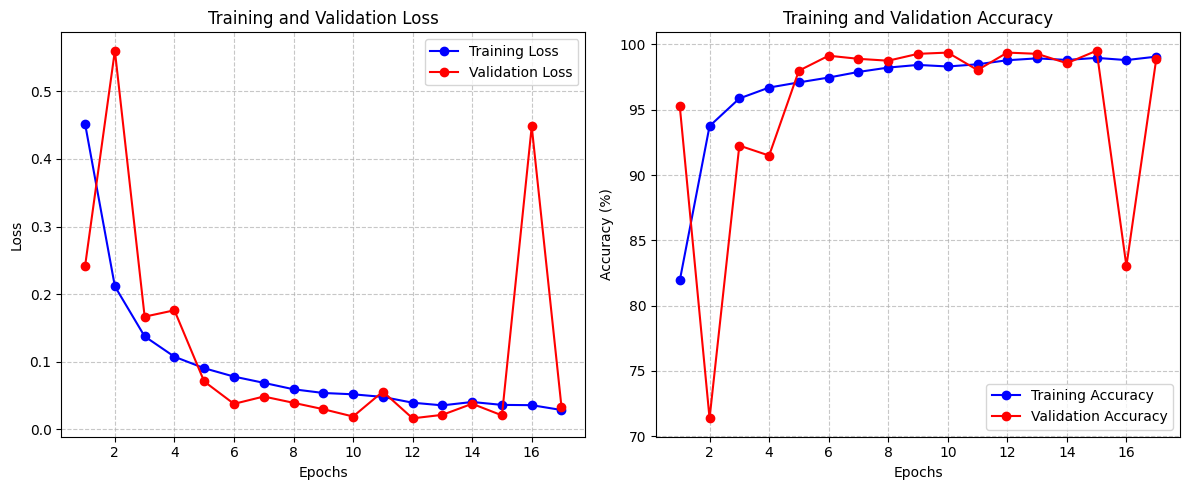

In [37]:
# 6. PLOT THE LEARNING CURVES

def plot_learning_curves(history):
    epochs_range = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Training Loss', color='blue', marker='o')
    plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='red', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Training Accuracy', color='blue', marker='o')
    plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', color='red', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Generate the plots!
plot_learning_curves(history)

<h1>Inference